# Evaluate Saved Checkpoint
Reload trained model (and optional temperature scaler) to score val/test and plot reliability.


In [1]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [2]:
# Choose device manually ("cpu" or "cuda"); set to None to auto-detect
DEVICE_OVERRIDE = None  # e.g., "cpu" to force CPU, "cuda" to force GPU if available

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Plot theming
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300, 'axes.titlesize': 12, 'axes.labelsize': 11, 'legend.fontsize': 10})

PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

def save_fig(fig, name: str, prefix: str = "train"):
    path = PLOTS_DIR / f"{prefix}_{name}.pdf"
    fig.savefig(path, bbox_inches='tight', format='pdf')
    print(f"Saved figure to {path}")
    return path


In [4]:

from utils import load_checkpoint
from training import Trainer
from validation import evaluate, reliability_bins, TemperatureScaler

ckpt_path = Path("../artifacts/checkpoints/best.pt")
model, cfg = load_checkpoint(str(ckpt_path))

if DEVICE_OVERRIDE:
    cfg.device_override = DEVICE_OVERRIDE

trainer = Trainer(cfg)
trainer.model = model.to(trainer.device)

temp_path = Path(cfg.checkpoints_dir) / "temperature.pt"
temperature = TemperatureScaler.load(temp_path, device=trainer.device) if temp_path.exists() else None
if temperature:
    temperature = temperature.to(trainer.device)


In [5]:
val_metrics, val_outputs = evaluate(
    trainer.model,
    trainer.val_loader,
    trainer.device,
    trainer.cfg,
    temperature=temperature,
)
test_metrics, test_outputs = evaluate(
    trainer.model,
    trainer.test_loader,
    trainer.device,
    trainer.cfg,
    temperature=temperature,
)
val_metrics, test_metrics

({'accuracy': 0.955,
  'macro_precision': 0.9585510190918473,
  'macro_recall': 0.9550000000000001,
  'macro_f1': 0.9549127110085125,
  'brier': 0.03399785907769945,
  'ece': 0.02577172872424125},
 {'accuracy': 0.9495,
  'macro_precision': 0.9532533913336338,
  'macro_recall': 0.9495,
  'macro_f1': 0.9493952354862654,
  'brier': 0.03960718088678548,
  'ece': 0.021208562463521985})

Saved figure to ../plots/evaluate_reliability_val.pdf


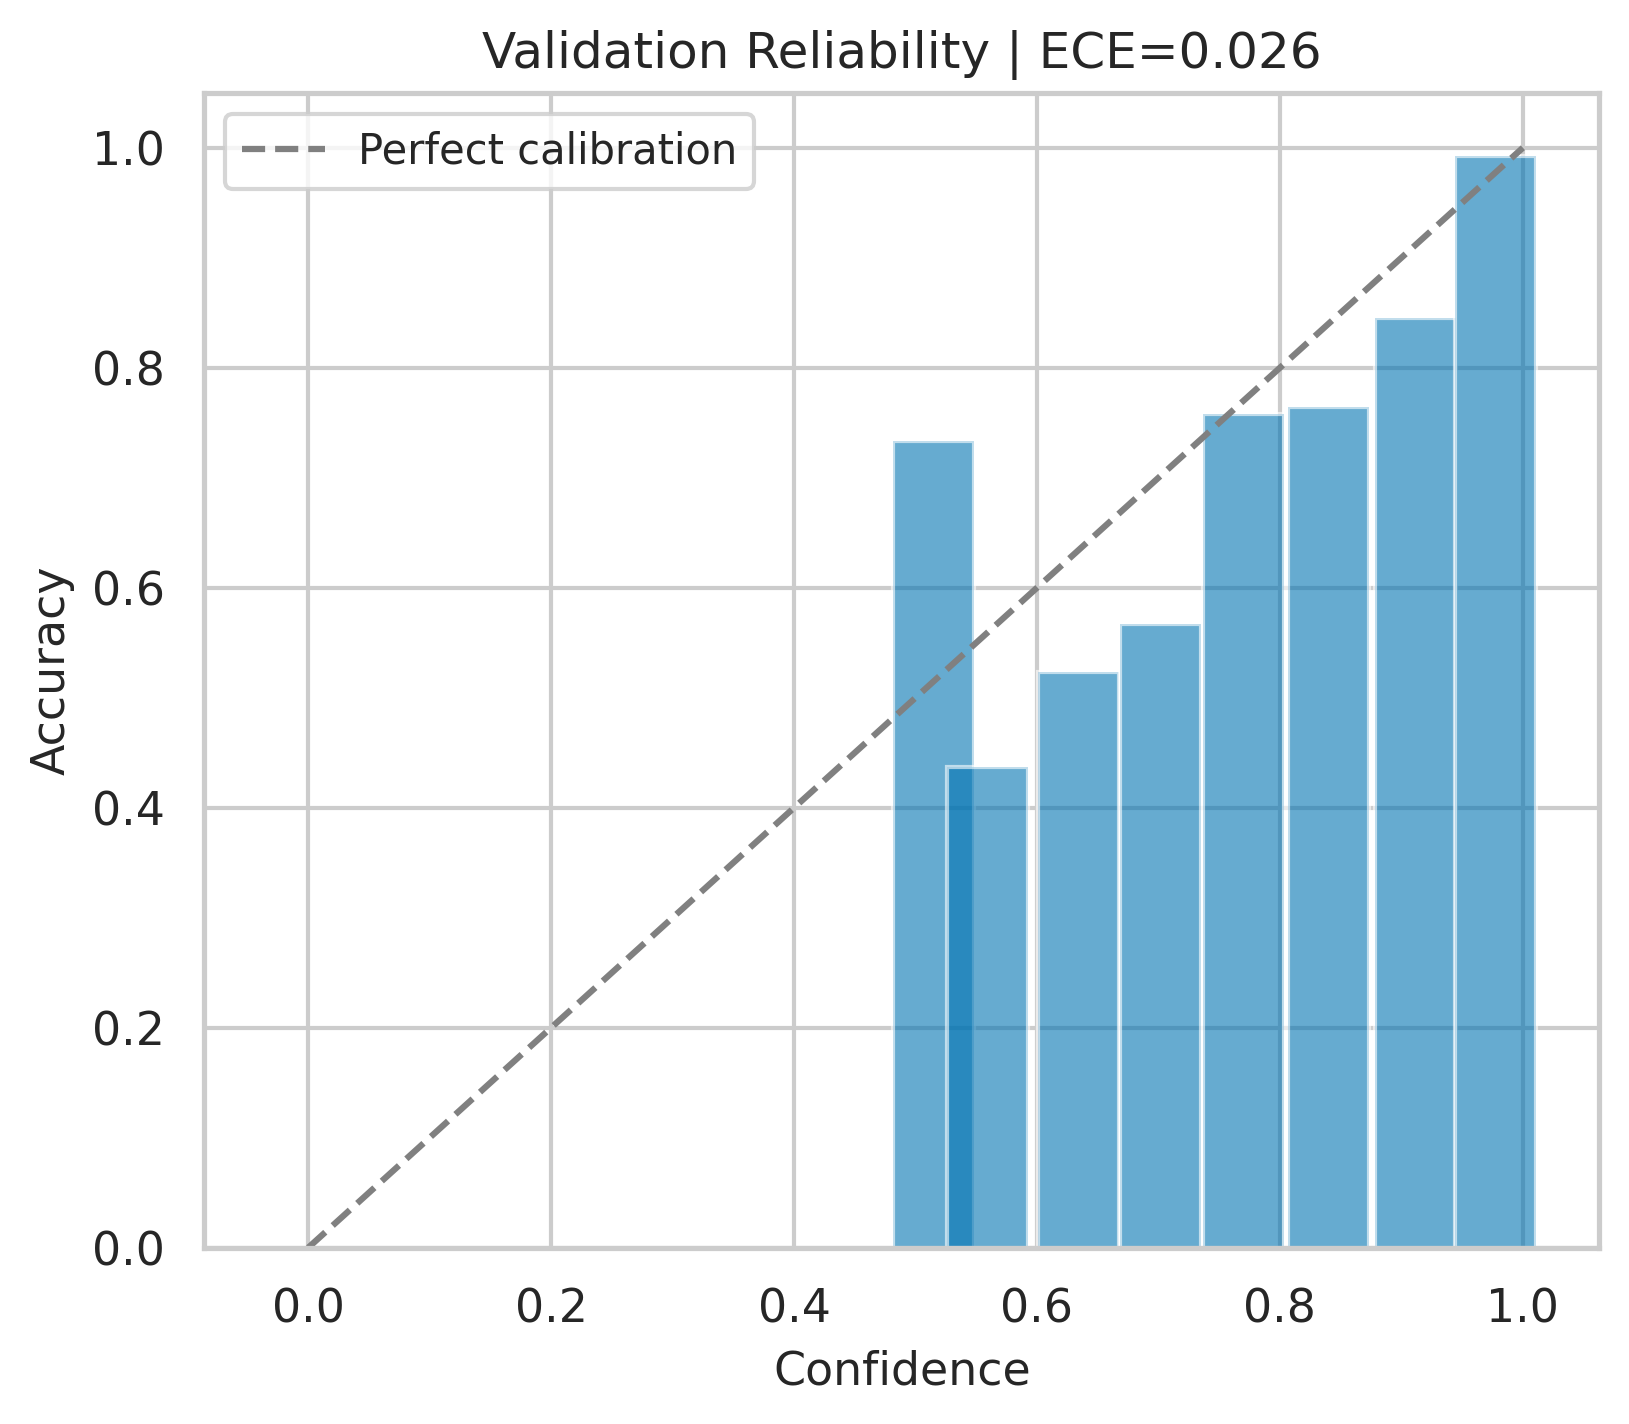

Saved figure to ../plots/evaluate_reliability_test.pdf


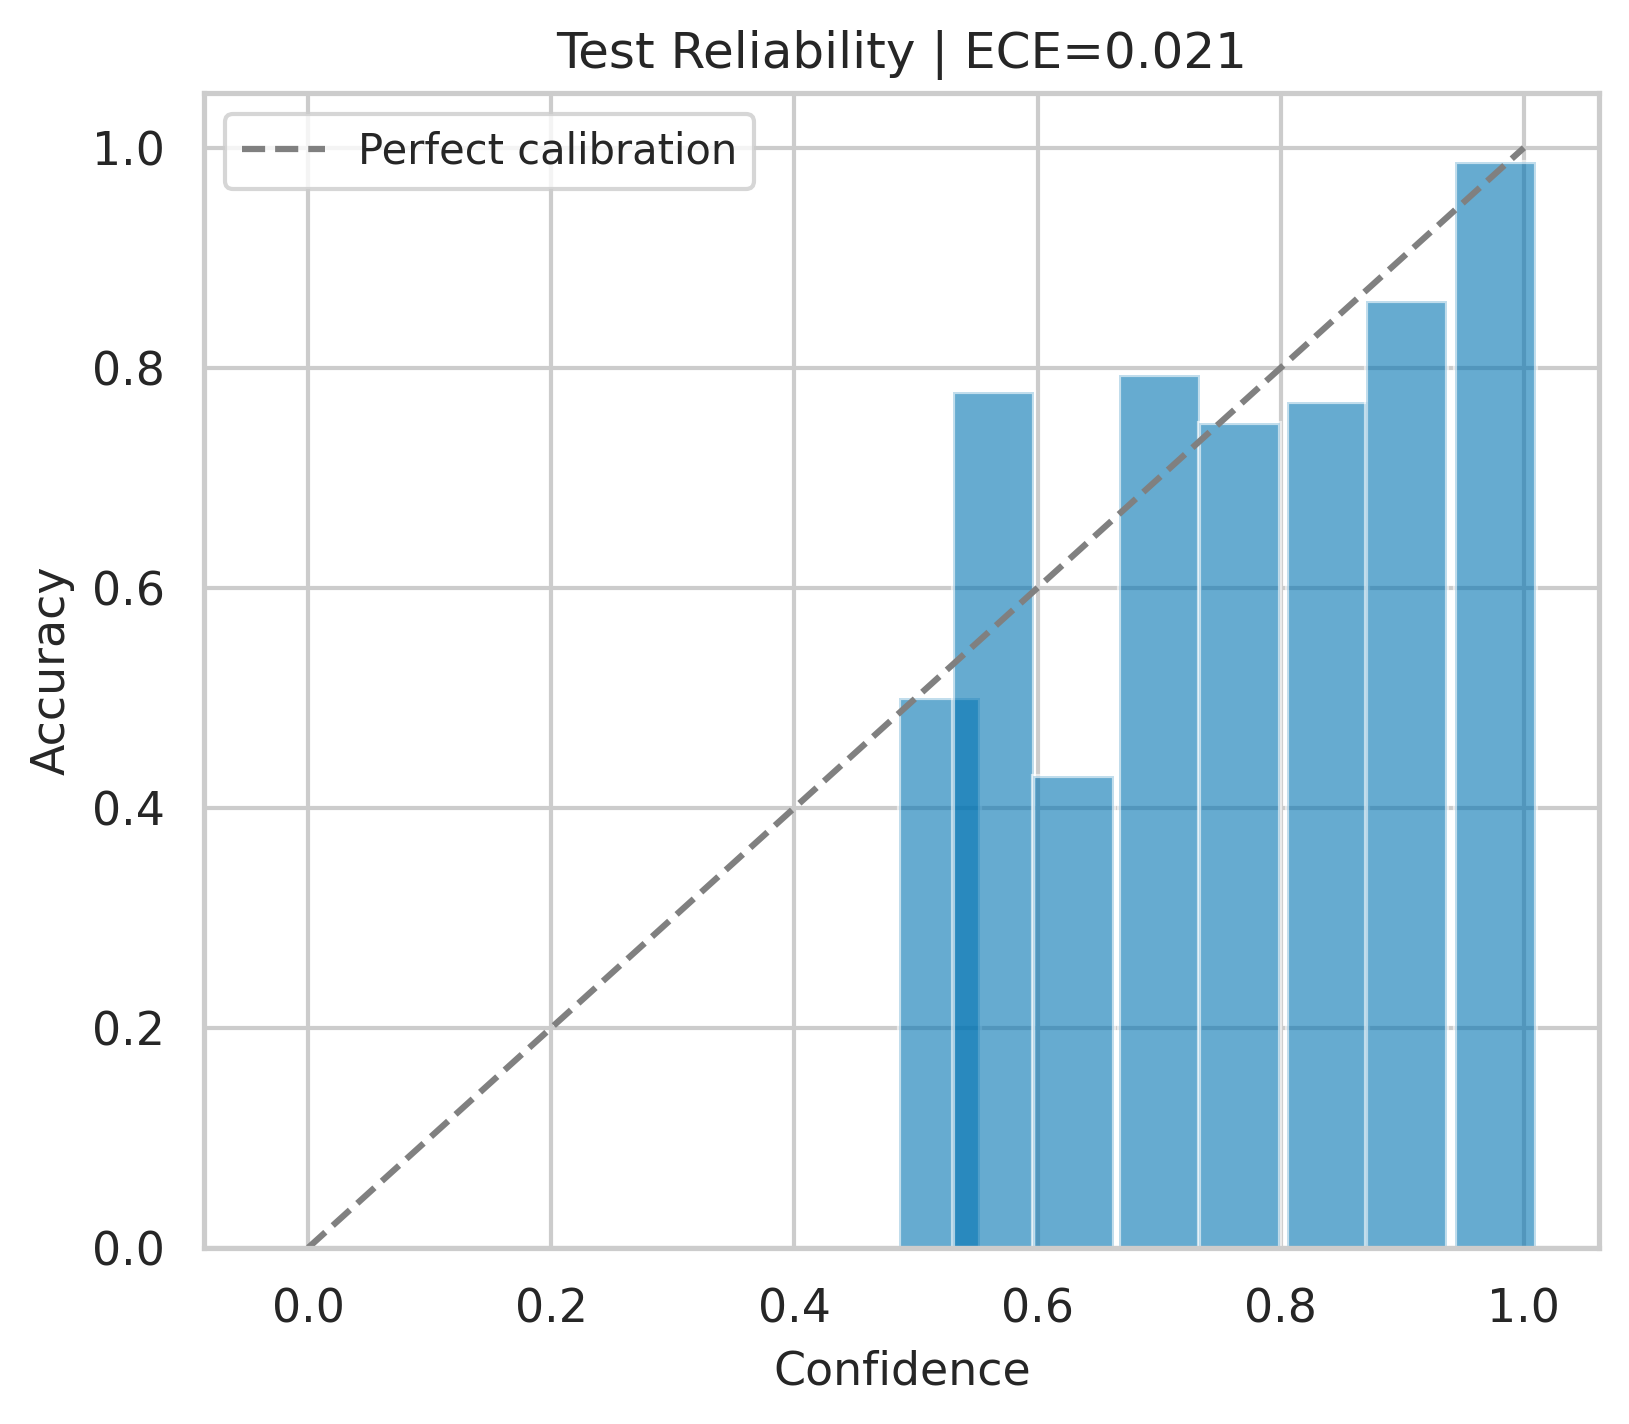

Saved figure to ../plots/evaluate_confusion_val.pdf


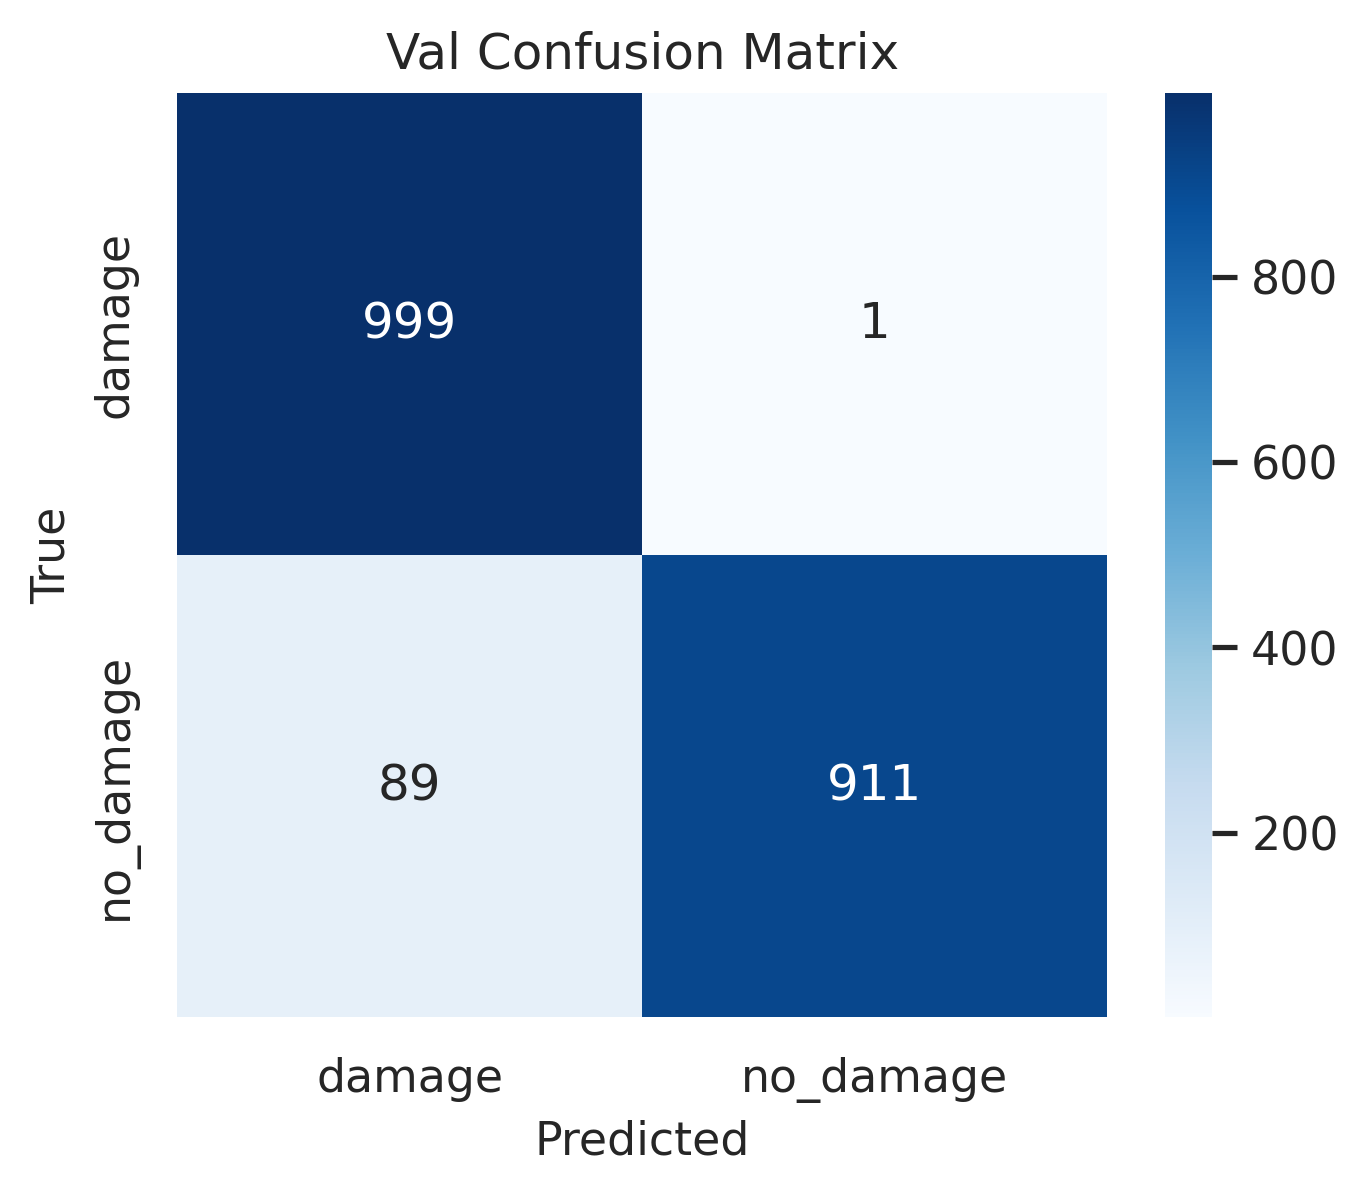

Saved figure to ../plots/evaluate_confusion_test.pdf


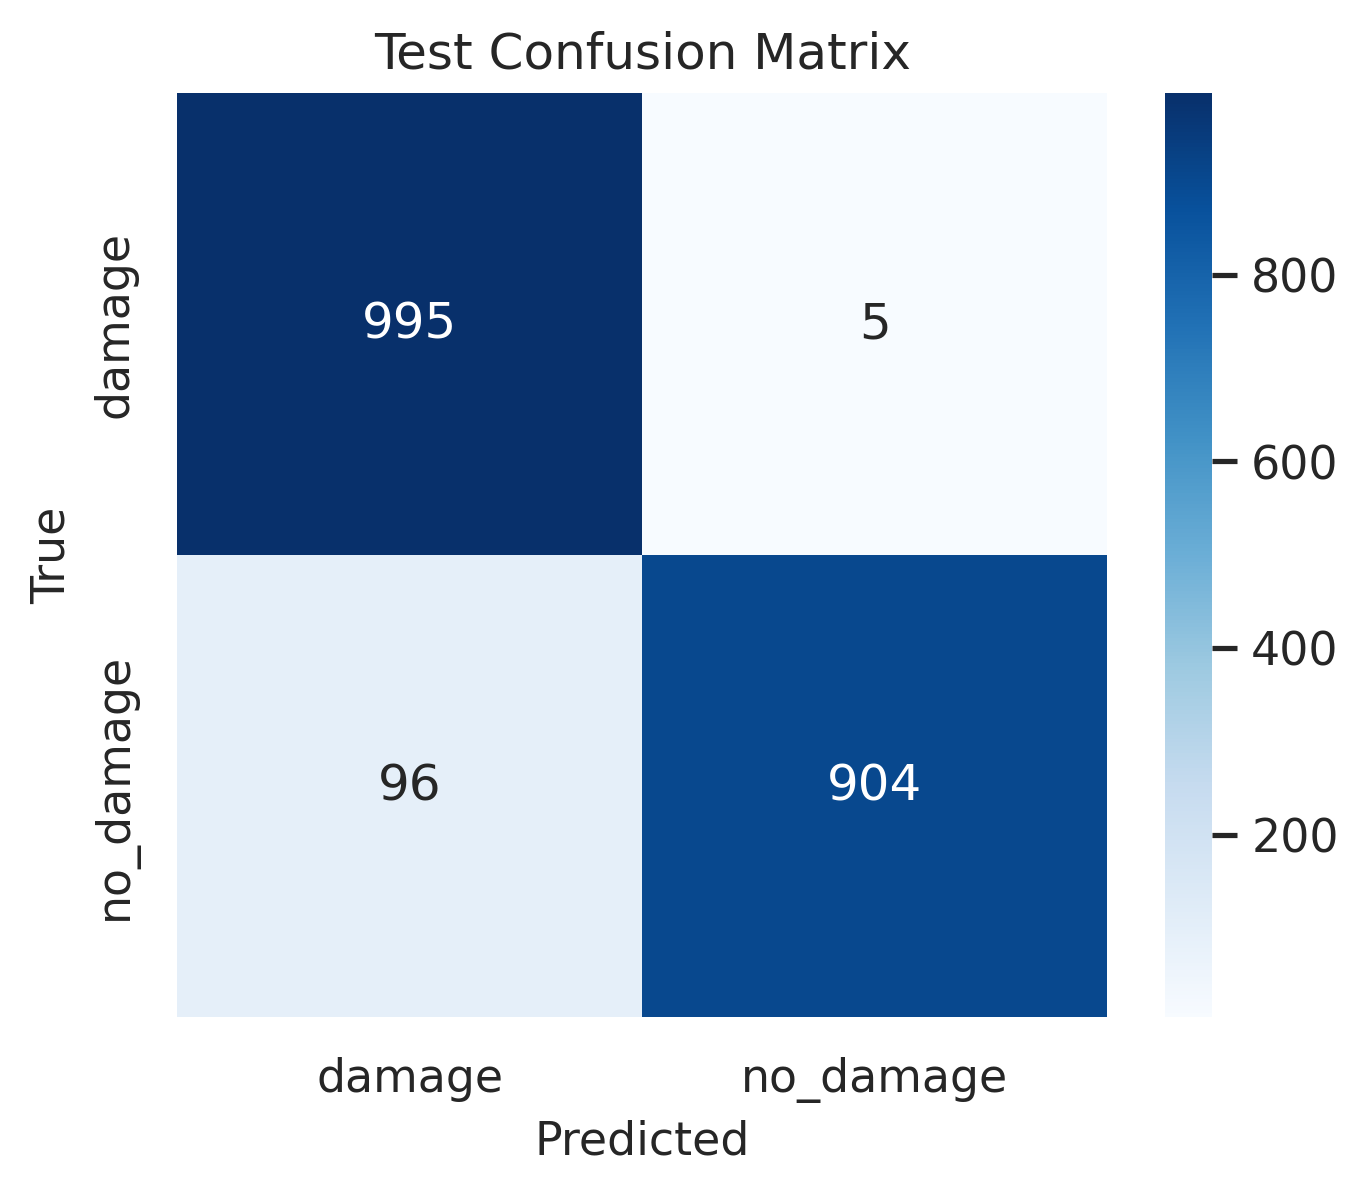

Saved figure to ../plots/evaluate_score_hist_val.pdf


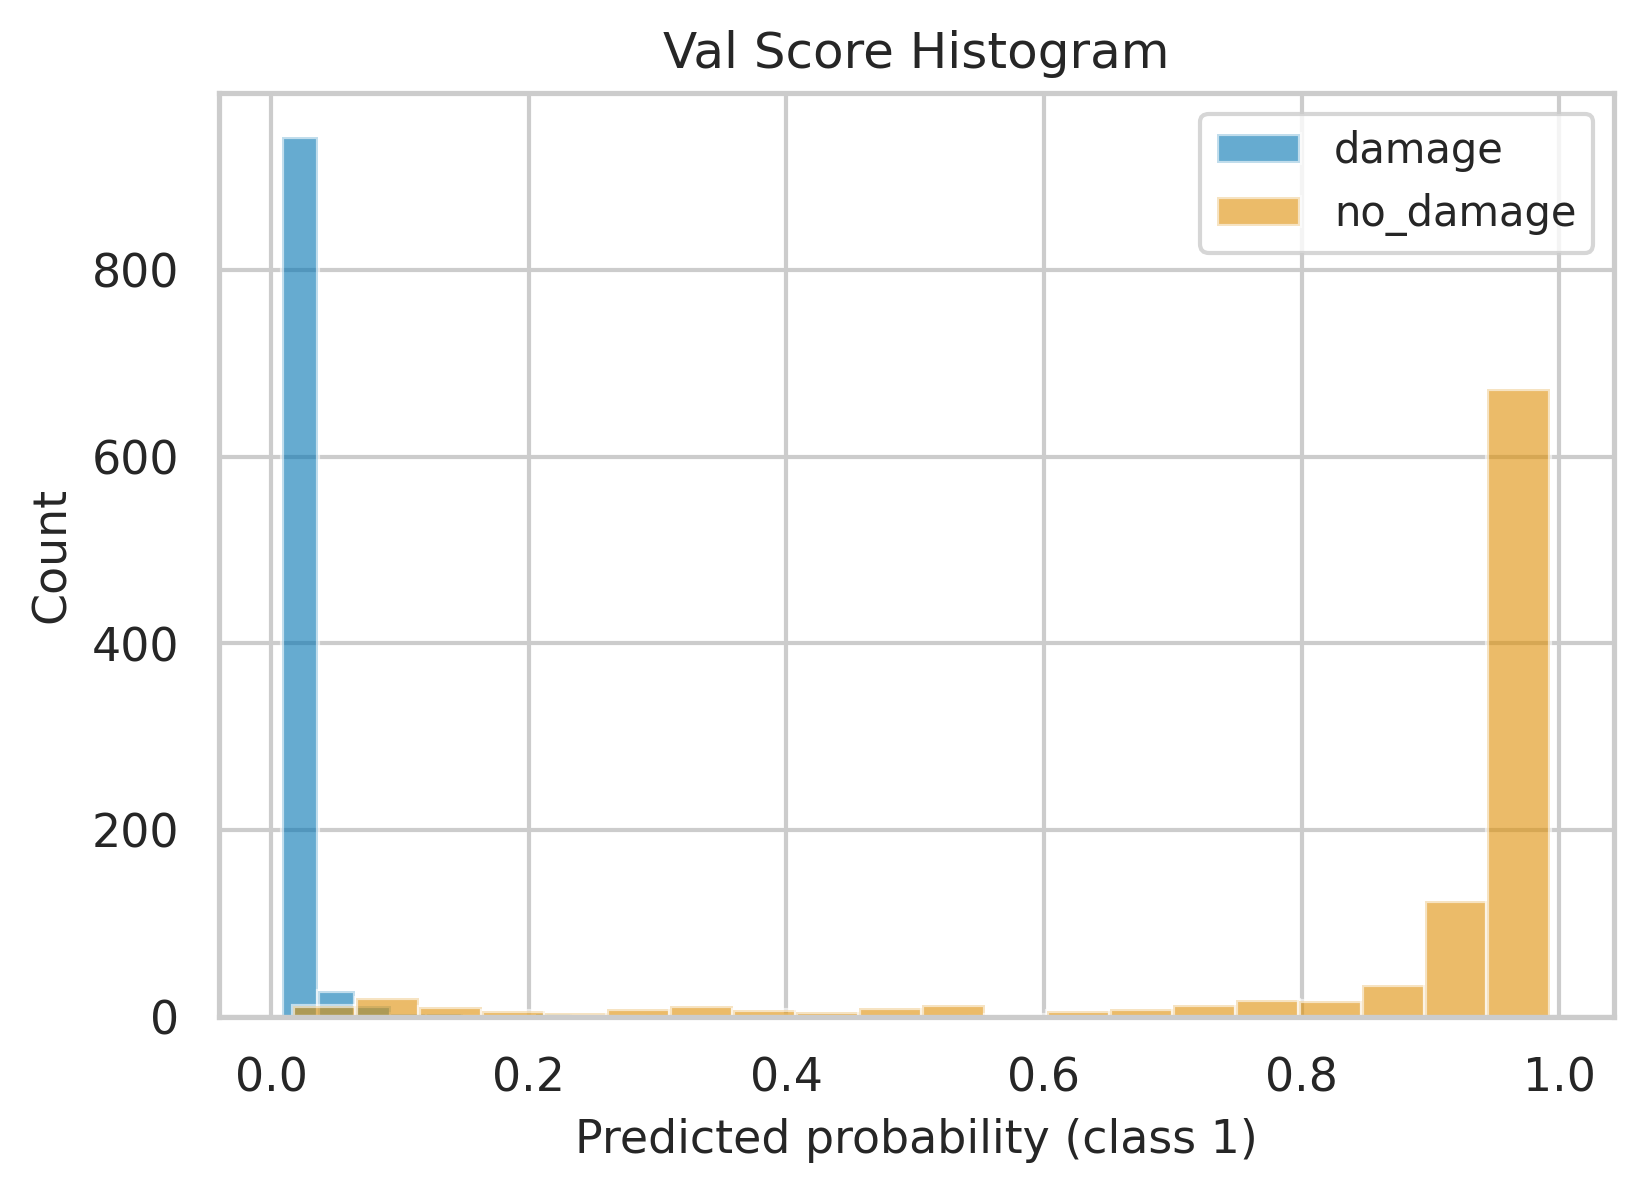

Saved figure to ../plots/evaluate_score_hist_test.pdf


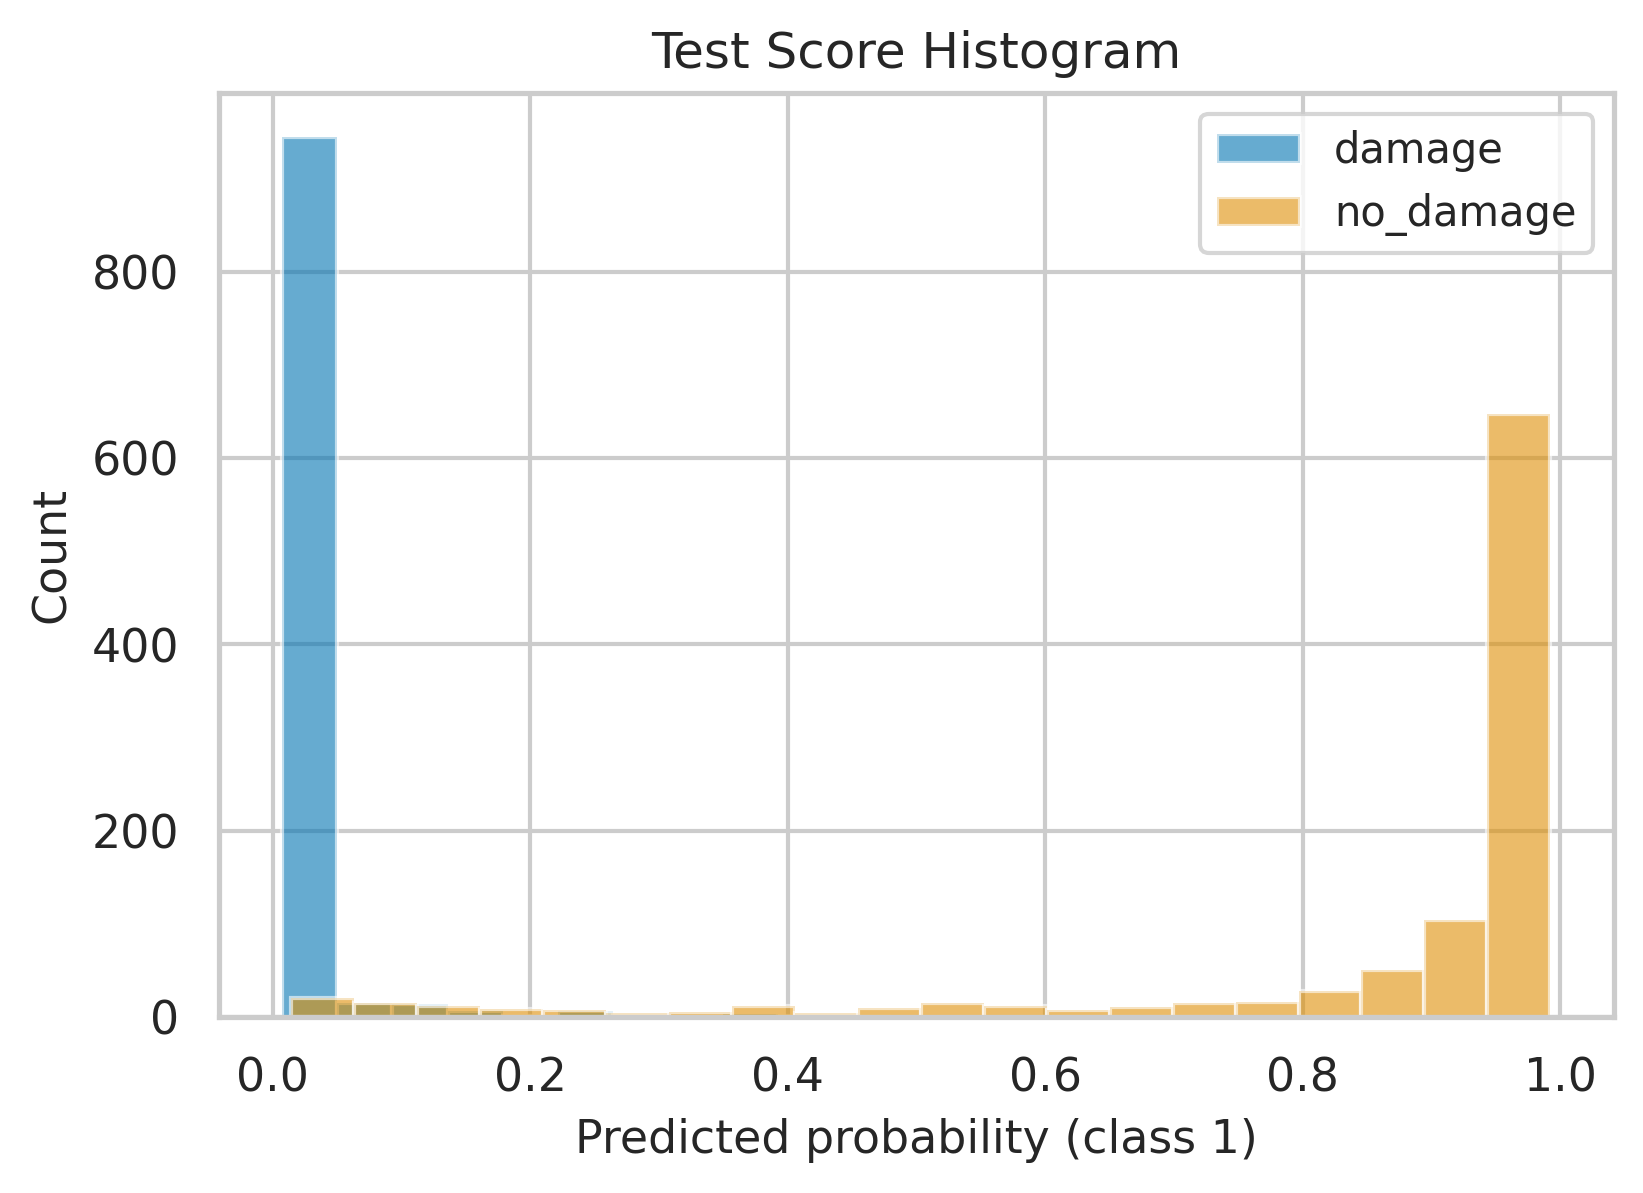

Saved figure to ../plots/evaluate_metrics.pdf


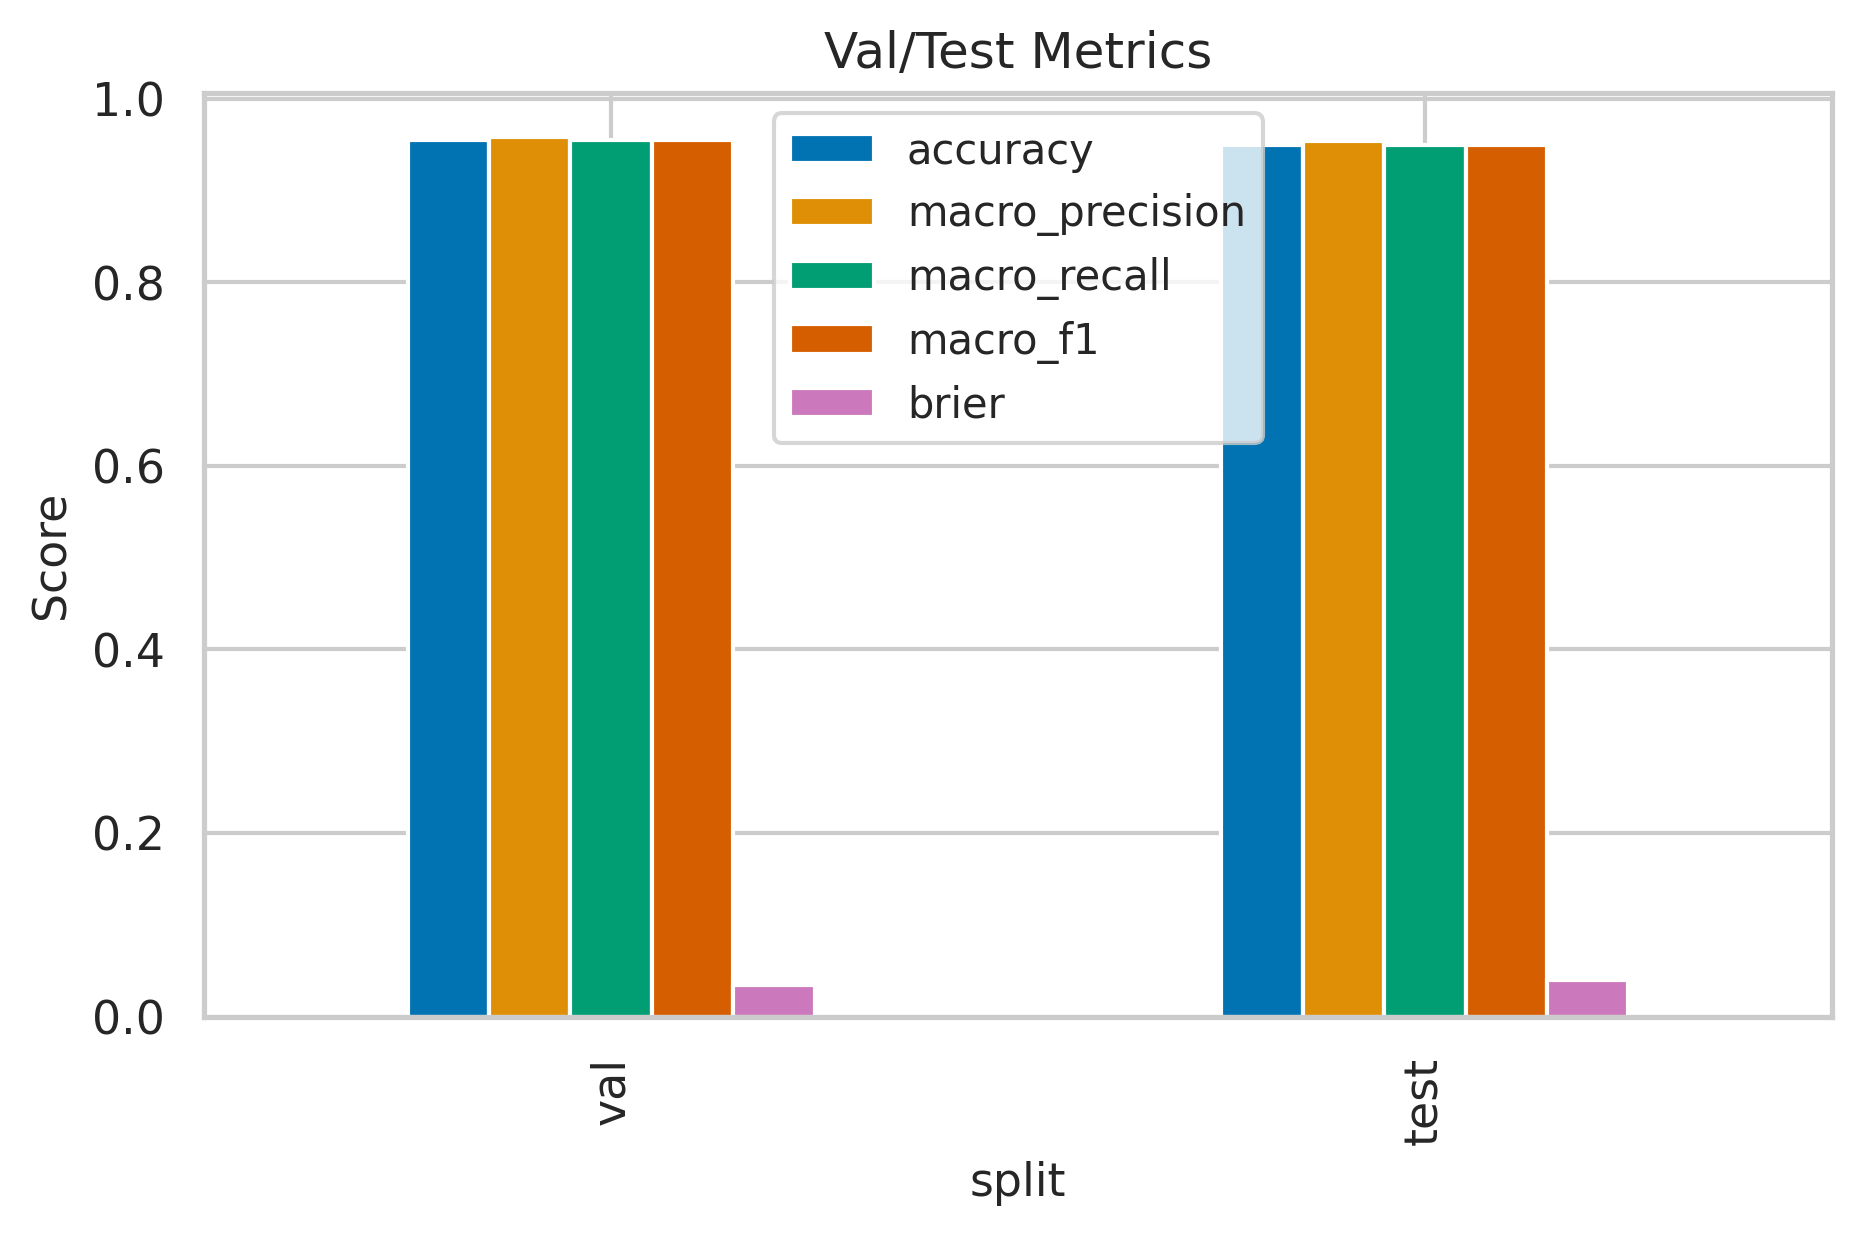

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Reliability on validation
bin_conf, bin_acc, bin_count = reliability_bins(
    val_outputs["probs"], val_outputs["labels"].cpu().numpy(), n_bins=trainer.cfg.reliability_bins
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_conf, bin_acc, width=1.0 / trainer.cfg.reliability_bins, alpha=0.6, align="center")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title(f"Validation Reliability | ECE={val_metrics['ece']:.3f}")
ax.legend()
save_fig(fig, "reliability_val", prefix="evaluate")
plt.show()

# Reliability on test
bin_conf_t, bin_acc_t, bin_count_t = reliability_bins(
    test_outputs["probs"], test_outputs["labels"].cpu().numpy(), n_bins=trainer.cfg.reliability_bins
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_conf_t, bin_acc_t, width=1.0 / trainer.cfg.reliability_bins, alpha=0.6, align="center")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title(f"Test Reliability | ECE={test_metrics['ece']:.3f}")
ax.legend()
save_fig(fig, "reliability_test", prefix="evaluate")
plt.show()

# Confusion matrices
class_names = trainer.datamodule.train_dataset.classes
for split_name, outputs in [("val", val_outputs), ("test", test_outputs)]:
    probs = outputs["probs"]
    labels = outputs["labels"].cpu().numpy()
    preds = probs.argmax(axis=1)
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{split_name.capitalize()} Confusion Matrix")
    save_fig(fig, f"confusion_{split_name}", prefix="evaluate")
    plt.show()

# Score histograms (positive class) for val/test
for split_name, outputs in [("val", val_outputs), ("test", test_outputs)]:
    probs = outputs["probs"]
    labels = outputs["labels"].cpu().numpy()
    pos_scores = probs[:, 1] if probs.shape[1] > 1 else probs[:, 0]
    fig, ax = plt.subplots(figsize=(6, 4))
    for label_val, label_name in enumerate(class_names):
        ax.hist(pos_scores[labels == label_val], bins=20, alpha=0.6, label=label_name)
    ax.set_xlabel("Predicted probability (class 1)")
    ax.set_ylabel("Count")
    ax.set_title(f"{split_name.capitalize()} Score Histogram")
    ax.legend()
    save_fig(fig, f"score_hist_{split_name}", prefix="evaluate")
    plt.show()

# Metric summary bar chart
summary_df = pd.DataFrame([
    {"split": "val", **val_metrics},
    {"split": "test", **test_metrics},
]).set_index("split")
fig, ax = plt.subplots(figsize=(7, 4))
summary_df[[c for c in summary_df.columns if c != "ece"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Val/Test Metrics")
save_fig(fig, "metrics", prefix="evaluate")
plt.show()
